# Моделирование распространения сигнала в аудитории 8507

### Импорты

In [132]:
import drjit as dr
import mitsuba as mi
import xml.etree.ElementTree as ET
import json
import edit_xml as ex
import os
import sionna as sn
from config import SCENE_MATERIALS, MATERIAL_COLORS
import tensorflow as tf  # Sionna работает на TF, нужен для конвертации тензоров
import numpy as np
import matplotlib.pyplot as plt


# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject, PlanarRadioMap, subcarrier_frequencies

from sionna.phy.channel.utils import cir_to_ofdm_channel


### Загрузка сцены

Файл `room.xml` изначально был создан в Blender 3.6. Сцена представляет собой кабинет, с двумя пространствами, отделенными друг от друга стеклянной перегородкой. 3D модель экспортирована с помощью плагина Mitsuba c кастомными настройками(вверх Z, вперед Y) По умолчанию загрузка сцены происходит с флагом `merge_shapes=True`, который объеденияет все объекты с одинаковыми радиоматериалами.

In [133]:
scene = load_scene("room.xml", merge_shapes=False)

Обработка файла, настройка отображения цвета, доопределение свойств материалов.

In [134]:
# Материалам при визуализации будут присвоены правильные цвета
ex.update_material_colors("room.xml", MATERIAL_COLORS)

# Присвоение элементам сцены таких же имен и ID, как и у объектов 3D модели
ex.set_shape_ids_from_filename("room.xml")


# Перезагрузка сцены, объекты не объединины по радиоматериалам
scene = load_scene("room.xml", merge_shapes=False)

print("Available objects:", list(scene.objects.keys()))

# Назначение радиоматериалов и толщины объектам сцены
ex.apply_materials_from_config(scene, SCENE_MATERIALS)


Available objects: ['wall', 'floor', 'partition', 'table2', 'table1', 'table3', 'comp1', 'comp2', 'comp3', 'point_001', 'point_002', 'point_003']


Создание экземпляров камер,визуализация.

In [135]:
cam = Camera(position=[0,0,10],  look_at=[0,0,0])
cam_1 = Camera(position=[10,-5,12], look_at=[0,0,0])

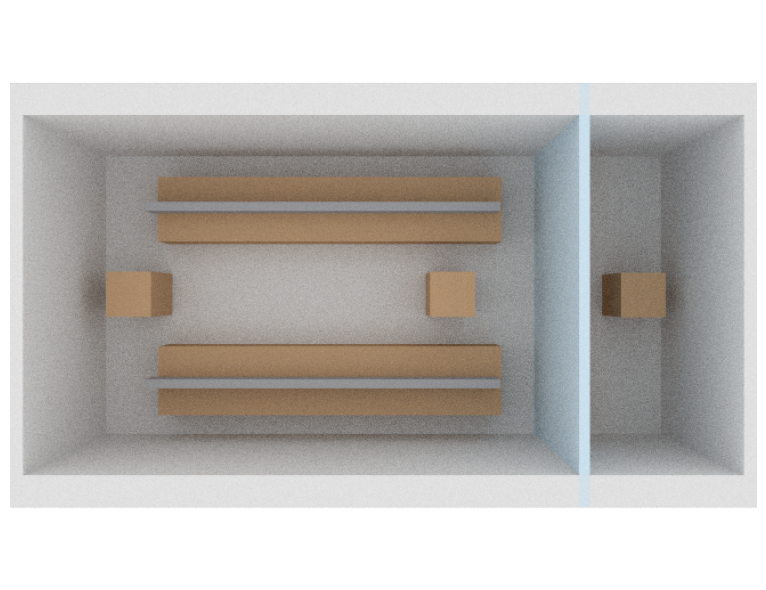

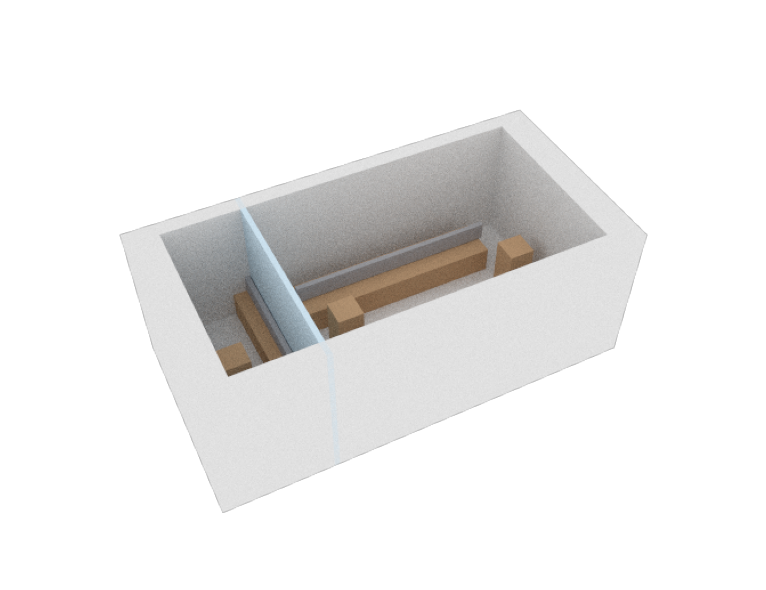

In [136]:
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

if no_preview:
    scene.render(camera=cam_1);
else:
    scene.preview();

In [137]:

# Позиции без изменений
tx_pos = [0, 2.82, -0.486 + 0.6+1]
rx_1_pos = [0, -2.92, -0.486 + 0.6]
rx_2_pos = [0, -0.766, -0.4853 + 0.6]

# Безопасная замена существующих объектов
for name in ["tx", "rx-1", "rx-2"]:
    scene.remove(name)

scene.add(Transmitter("tx", position=tx_pos, display_radius=0.01))
#scene.add(Receiver("rx-1", position=rx_1_pos, display_radius=0.01))
scene.add(Receiver("rx-2", position=rx_2_pos, display_radius=0.01))

# Антенная конфигурация, аппроксимирующая Intel AX210
ax210_array = PlanarArray(num_rows=1,
                          num_cols=1,
                          pattern="dipole",
                          polarization="VH")

scene.tx_array = ax210_array
scene.rx_array = ax210_array

In [138]:
#p_solver = PathSolver()
#paths = p_solver(scene, max_depth=2)

p_solver = PathSolver()
result = p_solver(
    scene=scene,
    max_depth=4,
    los=True,
    specular_reflection=True,
    refraction=True,
    diffuse_reflection=False,
    synthetic_array=False,
    seed=42
)


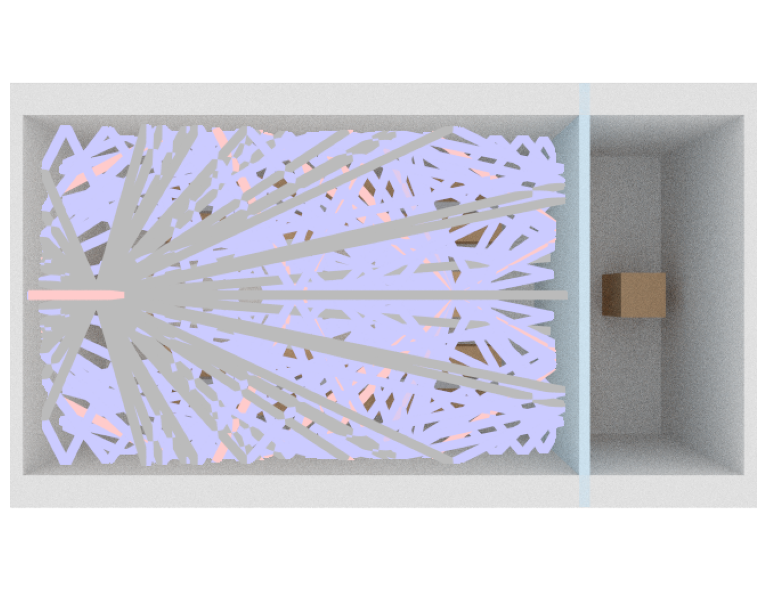

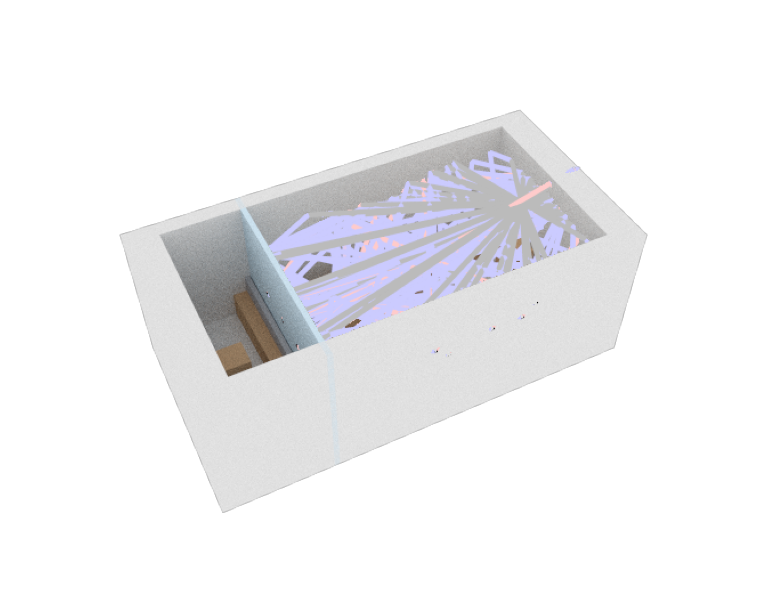

In [139]:
if no_preview:
    scene.render(camera=cam, paths=result);
else:
    scene.preview(paths=result)


if no_preview:
    scene.render(camera=cam_1, paths=result);
else:
    scene.preview(paths=result)

In [140]:
# Получение импульсной характеристики канала
a, tau = result.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 2, 69, 1)
Shape of tau:  (1, 2, 1, 2, 69)


Shape of h_freq:  (1, 2, 1, 2, 1, 256)


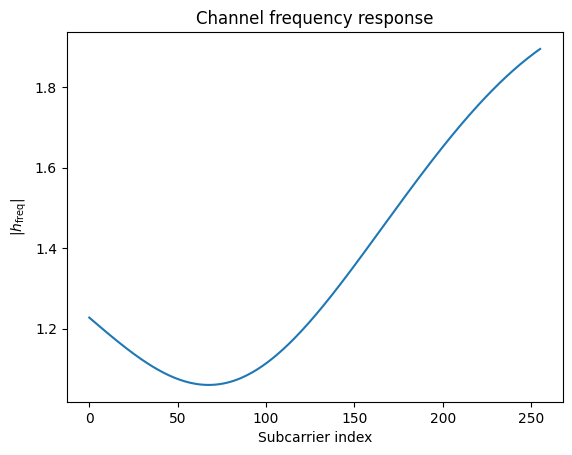

In [141]:
# OFDM system parameters
num_subcarriers = 256
subcarrier_spacing=subcarrier_spacing = 78.125e3  # 78.125 kHz


# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = result.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");